In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = os.path.abspath("..")
FIG = os.path.join(BASE, "outputs", "figures")
PROC = os.path.join(BASE, "data", "processed")
RAW = os.path.join(BASE, "data", "raw")

d = pd.read_csv(os.path.join(PROC, "dhaka_clean.csv"), parse_dates=["datetime", "datetime_local"])
w = pd.read_csv(os.path.join(RAW, "weather_dhaka.csv"), parse_dates=["datetime"])

df = d.merge(w, on="datetime", how="inner")
print(d.shape, w.shape, df.shape)
print(df[["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]].isnull().sum())

(28992, 14) (28992, 5) (28992, 18)
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
dtype: int64


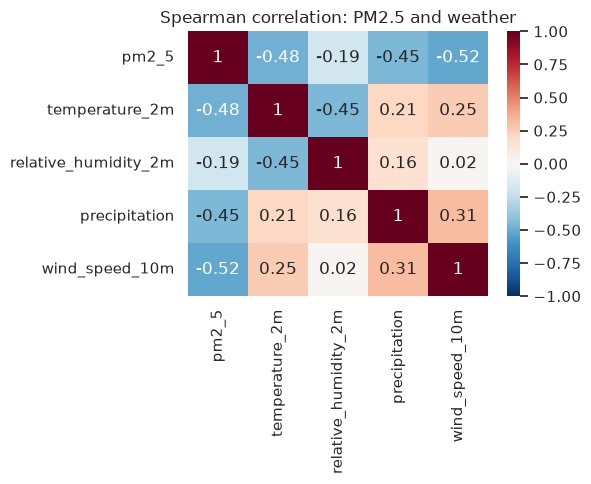

pm2_5                   1.00
temperature_2m         -0.48
relative_humidity_2m   -0.19
precipitation          -0.45
wind_speed_10m         -0.52
Name: pm2_5, dtype: float64

In [2]:
cols = ["pm2_5", "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]
corr = df[cols].corr(method="spearman").round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation: PM2.5 and weather")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "corr_heatmap.png"), dpi=150)
plt.show()

corr["pm2_5"]

In [3]:
df["rain_status"] = np.where(df["precipitation"] > 0, "Rain", "No rain")
print(df.groupby("rain_status")["pm2_5"].agg(["count", "mean", "median"]).round(1))

             count  mean  median
rain_status                     
No rain      23042  55.7    48.3
Rain          5950  21.2    16.2


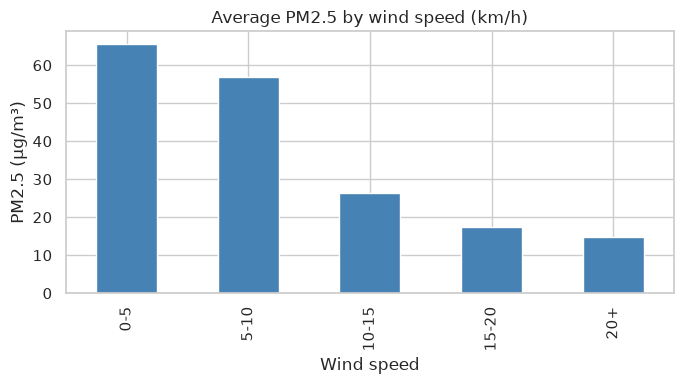

In [4]:
df["wind_bin"] = pd.cut(df["wind_speed_10m"], bins=[0, 5, 10, 15, 20, 100],
                        labels=["0-5", "5-10", "10-15", "15-20", "20+"])
wind = df.groupby("wind_bin", observed=True)["pm2_5"].mean()

ax = wind.plot(kind="bar", color="steelblue", figsize=(7, 4))
ax.set_title("Average PM2.5 by wind speed (km/h)")
ax.set_xlabel("Wind speed")
ax.set_ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "pm25_by_wind.png"), dpi=150)
plt.show()

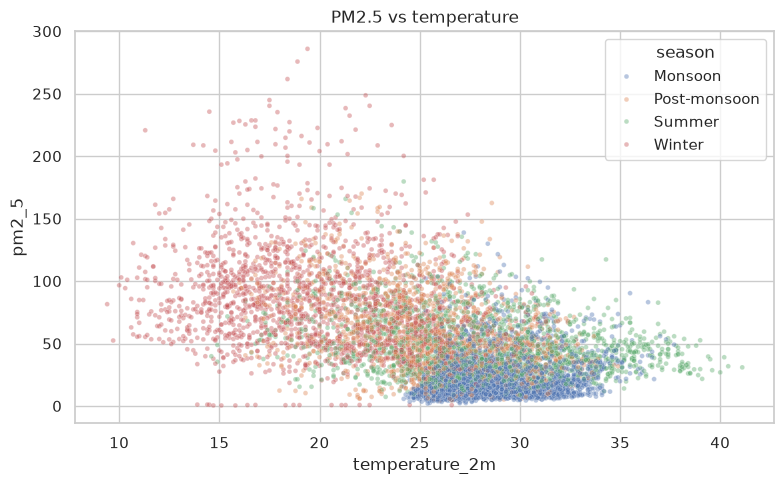

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(8000, random_state=1), x="temperature_2m", y="pm2_5",
                hue="season", alpha=0.4, s=12)
plt.title("PM2.5 vs temperature")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "pm25_vs_temp.png"), dpi=150)
plt.show()